# AAV9 fit4function -- Potts regression vs ProfileMLP (shallow & deep), Production1 -> Production2

Cross-replicate generalization check on `fit4functionaav9.csv` (same real dataset as
`ProfileMLP_train40_Production1_test60_Production2.ipynb` in `Modelization_V1`), redone here
with **three** methods trained the same way -- 40% of variants for training (`Production1` log2
enrichment as the target), the remaining 60% held out for testing -- so all three are directly
comparable:

1. **Potts regression** (`RegressionV1.fit_weights_potts_from_data`, joint ridge fit -- same
   method as `AAV9_potts_regression.ipynb`, applied here to `Production1` instead of `aav9.csv`'s
   `target`).
2. **ShallowProfileMLP** (this project's standard ~27k-param architecture).
3. **DeepProfileMLP** (~90k-param architecture: per-position embedding + pairwise branch +
   4-layer head, from `diversity_sweep_deeper_mlp.ipynb`).

Each is trained ONLY on `Production1` values from the 40% training split, then evaluated on the
held-out 60% against BOTH replicates: `Production1` (do predictions generalize to new variants
within the same replicate?) and `Production2` (do they generalize to an independent replicate,
i.e. did the model learn real signal or `Production1`'s own measurement noise?).
`r_replicate_ceiling` (Pearson r between `Production1` and `Production2` on the test rows) is
the reproducibility ceiling no method can be expected to beat.

No double-mutant-scan anywhere in this notebook (consistent with the rest of
`Modelization_V2`) -- both MLP architectures are evaluated purely by their own held-out
predictions, never by extracting effective F/J from them.

## 0. Setup

In [1]:
import sys, os

sys.path.insert(0, os.path.abspath("../../lib"))
sys.path.insert(0, os.path.abspath("."))
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"  # must be set before jax initializes

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

import jax
import jax.numpy as jnp
from flax import nnx
from typing import Optional
import optax
from tqdm.auto import tqdm

import RegressionV1 as R
from analysisV1 import AA_LABELS, pearson, precision_at_k, plot_topk_recovery

print(f"JAX backend: {jax.default_backend()} -- devices: {jax.devices()}")

message = "AAV9 fit4function: Potts vs ProfileMLP (shallow/deep), Production1 -> Production2, 1.0"

/home/spark0735/MERLIN_YASSINE/Directed-Evolution-loop/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


JAX backend: gpu -- devices: [CudaDevice(id=0)]


## 1. Load data + log2 enrichment (both replicates valid)

Same filter as `ProfileMLP_train40_Production1_test60_Production2.ipynb`: only rows where
BOTH `Production1` and `Production2` are finite and strictly positive are kept (log2
undefined otherwise).

In [2]:
df = pd.read_csv("fit4functionaav9.csv")
print(f"{len(df):,} rows, columns: {list(df.columns)}")

p1 = df["Production1"].to_numpy(dtype=float)
p2 = df["Production2"].to_numpy(dtype=float)
valid = np.isfinite(p1) & (p1 > 0) & np.isfinite(p2) & (p2 > 0)
print(f"kept {valid.sum():,}/{len(df):,} rows ({valid.sum() / len(df):.1%}) with a valid "
      f"(finite, >0) value in BOTH Production1 and Production2")

df = df.loc[valid].reset_index(drop=True)
log2_p1 = np.log2(df["Production1"].to_numpy(dtype=float))
log2_p2 = np.log2(df["Production2"].to_numpy(dtype=float))

74,464 rows, columns: ['AA', 'CodonRep1', 'CodonRep2', 'Label', 'Production1', 'Production2', 'Production']
kept 54,621/74,464 rows (73.4%) with a valid (finite, >0) value in BOTH Production1 and Production2


## 2. Sequence encoding

In [3]:
lengths = df["AA"].str.len().unique()
assert len(lengths) == 1, f"expected a single sequence length, got {lengths}"
num_positions = int(lengths[0])
num_amino_acids = len(AA_LABELS)

alphabet = sorted(set("".join(df["AA"])))
assert alphabet == AA_LABELS, f"alphabet mismatch: {alphabet} vs {AA_LABELS}"

lut = np.zeros(256, dtype=np.int64)
for i, aa in enumerate(AA_LABELS):
    lut[ord(aa)] = i

seq_bytes  = np.frombuffer("".join(df["AA"]).encode("ascii"), dtype=np.uint8)
seq_matrix = lut[seq_bytes].reshape(len(df), num_positions)          # (N, L) raw indices -- Potts regression
seq_oh     = np.eye(num_amino_acids, dtype=np.float32)[seq_matrix]   # (N, L, A)
seq_oh     = seq_oh.reshape(len(df), -1)                             # (N, L*A) one-hot -- ProfileMLP

print(f"seq_matrix shape: {seq_matrix.shape}  seq_oh shape: {seq_oh.shape}")

seq_matrix shape: (54621, 7)  seq_oh shape: (54621, 140)


## 3. Split: 40% train (Production1 target) / 60% test (both replicates)

The 40/60 split is on VARIANTS (same held-out row set for every method below) -- only the
target column read for training differs from what's used to score the test set. Same
`train_size=0.40, random_state=0` convention as
`ProfileMLP_train40_Production1_test60_Production2.ipynb`, so results stay comparable to that
notebook's own numbers.

In [4]:
idx_train, idx_test = train_test_split(np.arange(len(df)), train_size=0.40, random_state=0)

y_train_full = log2_p1[idx_train]   # Production1 log2 enrichment -- the ONLY training target
y_test_p1    = log2_p1[idx_test]    # held-out variants, Production1 (within-replicate check)
y_test_p2    = log2_p2[idx_test]    # held-out variants, Production2 (cross-replicate check)

r_replicate_ceiling = pearson(log2_p1[idx_test], log2_p2[idx_test])

print(f"train (40%): {len(idx_train):,}   test (60%): {len(idx_test):,}   "
      f"(of {len(df):,} total)")
print(f"r_replicate_ceiling = r(Production1, Production2), test rows) = {r_replicate_ceiling:.4f}")
print("(no method below can be expected to beat this -- it's how well the two real replicates "
      "agree with each other)")

train (40%): 21,848   test (60%): 32,773   (of 54,621 total)
r_replicate_ceiling = r(Production1, Production2), test rows) = 0.8906
(no method below can be expected to beat this -- it's how well the two real replicates agree with each other)


## 4. Part A -- Potts regression

Joint ridge regression (`RegressionV1.fit_weights_potts_from_data`), fit ONLY on the 40%
training rows using `Production1` log2 enrichment as target -- same method and same function
as `AAV9_potts_regression.ipynb`, just applied to `fit4functionaav9.csv` instead of `aav9.csv`.
No separate train/val split needed here (unlike the MLPs below): the function's own 5-fold CV
already serves that role.

In [5]:
F_fit, J_fit, rank_train, info_train = R.fit_weights_potts_from_data(
    seq_matrix[idx_train], y_train_full, seed=0,
)
F_fit, J_fit = np.array(F_fit, dtype=np.float64), np.array(J_fit, dtype=np.float64)

lambdas_grid was not defined thus lambdas_grid = [  0.1          0.1268961    0.1610262    0.20433597   0.25929438
   0.32903446   0.41753189   0.52983169   0.67233575   0.85316785
   1.08263673   1.3738238    1.74332882   2.21221629   2.8072162
   3.56224789   4.52035366   5.73615251   7.27895384   9.23670857
  11.72102298  14.87352107  18.87391822  23.9502662   30.39195382
  38.56620421  48.93900918  62.10169419  78.80462816 100.        ]


Design matrix rank: 7715 / 8541 features (21848 obs)
  NOTE: rank-deficient design (p > n) -- ridge is not just a preference, the unregularized fit below is non-unique.



Ridge CV (aav9):   0%|          | 0/5 [00:00<?, ?it/s]


Ridge CV (aav9):  20%|██        | 1/5 [00:45<03:00, 45.16s/it]


Ridge CV (aav9):  40%|████      | 2/5 [01:30<02:15, 45.18s/it]


Ridge CV (aav9):  60%|██████    | 3/5 [02:15<01:30, 45.04s/it]


Ridge CV (aav9):  80%|████████  | 4/5 [03:00<00:44, 44.99s/it]


Ridge CV (aav9): 100%|██████████| 5/5 [03:45<00:00, 45.00s/it]

Best lambda: 23.9503


### 4a. Score the held-out 60%

`score_FJ` (same helper as `AAV9_potts_regression.ipynb` sections 4-5): a plain F+J score,
not tied to a `Protocol` instance, works on any raw sequence matrix directly. The regression's
own bias coefficient isn't exposed by `fit_weights_potts` (only the `F`/`J` tensors are
returned), so `baseline` is added back explicitly as the training target's own mean -- same
convention as `AAV9_potts_regression.ipynb`.

In [6]:
def score_FJ(seq, F, J, baseline):
    L = seq.shape[1]
    F_part = F[seq, np.arange(L)].sum(axis=1).astype(np.float64)
    J_part = np.zeros(len(seq), dtype=np.float64)
    for i in range(L):
        for j in range(i + 1, L):
            J_part += J[i, j, seq[:, i], seq[:, j]]
    return F_part, J_part, baseline + F_part + J_part


baseline_train = float(y_train_full.mean())
_, _, pred_potts_test = score_FJ(seq_matrix[idx_test], F_fit, J_fit, baseline_train)

r_potts_vs_p1 = pearson(y_test_p1, pred_potts_test)
r_potts_vs_p2 = pearson(y_test_p2, pred_potts_test)

print(f"Potts regression, held-out {len(idx_test):,} variants:")
print(f"  r(prediction, Production1 test) = {r_potts_vs_p1:+.4f}   (within-replicate)")
print(f"  r(prediction, Production2 test) = {r_potts_vs_p2:+.4f}   (cross-replicate; "
      f"ceiling = {r_replicate_ceiling:+.4f})")

Potts regression, held-out 32,773 variants:
  r(prediction, Production1 test) = +0.7978   (within-replicate)
  r(prediction, Production2 test) = +0.7968   (cross-replicate; ceiling = +0.8906)


### 4b. Percentile recovery (Potts regression vs Production2)

Same sweep as `AAV9_potts_GT_score_study.ipynb` section 2c, applied here to a genuine
held-out test set: for each percentile k, does the model's own top-k% (by predicted score)
recover the REAL top-k% (ranked by the held-out `Production2` measurement)?

Potts regression: recovery of the real top-k% (Production2) within the model's own top-k%:


,k,recovery,random_baseline
percentile,,,
1,327,0.045872,0.01
2,655,0.093130,0.02
5,1638,0.197192,0.05
10,3277,0.328349,0.10
20,6554,0.547605,0.20
30,9831,0.707151,0.30
50,16386,0.860002,0.50
70,22941,0.891417,0.70
100,32773,1.000000,1.00


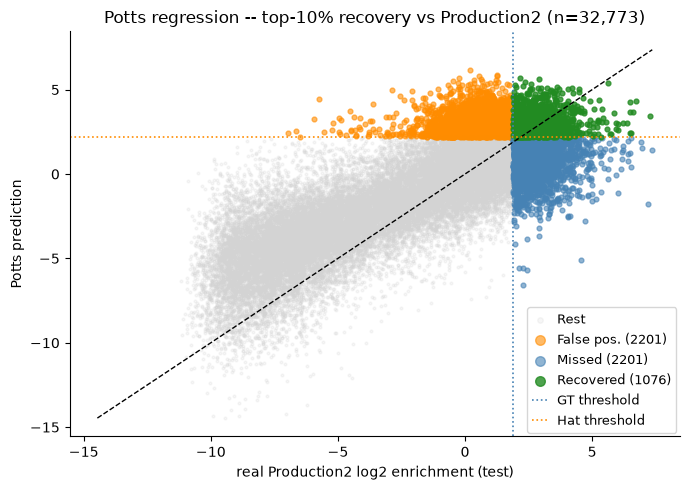

In [7]:
PERCENTILES = [1, 2, 5, 10, 20, 30, 50, 70, 100]

def recovery_table(y_true_test, y_pred_test, n):
    rows = []
    for pct in PERCENTILES:
        k_frac = pct / 100
        k = max(1, int(n * k_frac))
        rows.append(dict(percentile=pct, k=k,
                          recovery=precision_at_k(y_true_test, y_pred_test, k_frac=k_frac),
                          random_baseline=k_frac))
    return pd.DataFrame(rows).set_index("percentile")

potts_recovery_df = recovery_table(y_test_p2, pred_potts_test, len(idx_test))
print("Potts regression: recovery of the real top-k% (Production2) within the model's own top-k%:")
display(potts_recovery_df)

fig = plot_topk_recovery(y_test_p2, pred_potts_test, k_frac=0.10,
                          xlabel="real Production2 log2 enrichment (test)", ylabel="Potts prediction",
                          title=f"Potts regression -- top-10% recovery vs Production2 (n={len(idx_test):,})")
plt.show()

## 5. Part B -- ProfileMLP, shallow and deep

Both architectures trained the SAME way, on the SAME `Xtr`/`ytr`/`Xva`/`Xva` (the 40% training
chunk, further split 85/15 train/val, `Production1` as target) -- only the model differs, so
any gap between them isn't confounded by different data or training budget.

- **`ShallowProfileMLP`** -- this project's standard architecture (Linear+BatchNorm+Dropout+GELU
  x2, then a scalar head), ~27k params.
- **`DeepProfileMLP`** -- shared per-position embedding, average-pooled profile branch AND
  average-pooled pairwise branch (over all 21 position pairs), concatenated with the raw
  one-hot input, then a 4-hidden-layer dense head, ~90k params. Verbatim from
  `diversity_sweep_deeper_mlp.ipynb` (no mutant-scan in that notebook either).

In [8]:
class ShallowProfileMLP(nnx.Module):
    """This project's standard ProfileMLP (Linear + BatchNorm + Dropout + gelu, twice, then a
    scalar linear head) over the 140-d one-hot input."""

    def __init__(self, input_dim: int, hidden_dims: tuple[int, int] = (128, 64),
                 dropout_rate: float = 0.1, *, rngs: nnx.Rngs):
        h1, h2 = hidden_dims
        self.linear1    = nnx.Linear(input_dim, h1, rngs=rngs)
        self.batchnorm1 = nnx.BatchNorm(h1, use_running_average=False, rngs=rngs)
        self.dropout1   = nnx.Dropout(rate=dropout_rate, rngs=rngs)
        self.linear2    = nnx.Linear(h1, h2, rngs=rngs)
        self.batchnorm2 = nnx.BatchNorm(h2, use_running_average=False, rngs=rngs)
        self.dropout2   = nnx.Dropout(rate=dropout_rate, rngs=rngs)
        self.linear3    = nnx.Linear(h2, 1, rngs=rngs)

    def __call__(self, x, train: bool, rngs: nnx.Rngs = None):
        x = self.linear1(x)
        self.batchnorm1.use_running_average = not train
        x = self.batchnorm1(x)
        x = nnx.gelu(x)
        x = self.dropout1(x, rngs=rngs) if train else x
        x = self.linear2(x)
        self.batchnorm2.use_running_average = not train
        x = self.batchnorm2(x)
        x = nnx.gelu(x)
        x = self.dropout2(x, rngs=rngs) if train else x
        x = self.linear3(x)
        return x[:, 0]


class PositionEmbed(nnx.Module):
    """Shared per-position embedding: maps each position's 20-d one-hot to a d_emb-d learned
    embedding via ONE Linear+GELU, SAME weights applied to all L=7 positions."""

    def __init__(self, A: int, d_emb: int, *, rngs: nnx.Rngs):
        self.linear = nnx.Linear(A, d_emb, rngs=rngs)

    def __call__(self, x_pos):  # (batch, L, A)
        return nnx.gelu(self.linear(x_pos))  # (batch, L, d_emb)


class PairwiseHead(nnx.Module):
    """For every one of the L*(L-1)/2 unordered position pairs (i,j): concatenate the two
    positions' embeddings, pass through a small shared 2-layer MLP, then average-pool over all
    pairs."""

    def __init__(self, L: int, d_emb: int, d_pair: int, *, rngs: nnx.Rngs):
        self.pairs_i = jnp.array([i for i in range(L) for j in range(i + 1, L)])
        self.pairs_j = jnp.array([j for i in range(L) for j in range(i + 1, L)])
        self.linear1 = nnx.Linear(2 * d_emb, 2 * d_pair, rngs=rngs)
        self.linear2 = nnx.Linear(2 * d_pair, d_pair, rngs=rngs)

    def __call__(self, emb):  # emb: (batch, L, d_emb)
        e_i = emb[:, self.pairs_i, :]
        e_j = emb[:, self.pairs_j, :]
        pair_feat = jnp.concatenate([e_i, e_j], axis=-1)
        h = nnx.gelu(self.linear1(pair_feat))
        h = self.linear2(h)
        return jnp.mean(h, axis=1)  # average pool over the 21 pairs -> (batch, d_pair)


class DeepProfileMLP(nnx.Module):
    """Per-position embedding -> [avg-pooled profile branch, avg-pooled pairwise branch, raw
    one-hot] concatenated -> a 4-hidden-layer dense head."""

    def __init__(self, L: int, A: int, d_emb: int = 16, d_pair: int = 16,
                 hidden_dims: tuple = (256, 128, 64, 32), dropout_rate: float = 0.1,
                 *, rngs: nnx.Rngs):
        self.L, self.A = L, A
        self.pos_embed = PositionEmbed(A, d_emb, rngs=rngs)
        self.pairwise  = PairwiseHead(L, d_emb, d_pair, rngs=rngs)

        input_dim = d_emb + d_pair + L * A
        dims = (input_dim,) + hidden_dims
        n_layers = len(hidden_dims)
        self.linears    = nnx.List([nnx.Linear(dims[i], dims[i + 1], rngs=rngs) for i in range(n_layers)])
        self.batchnorms = nnx.List([nnx.BatchNorm(dims[i + 1], use_running_average=False, rngs=rngs) for i in range(n_layers)])
        self.dropouts   = nnx.List([nnx.Dropout(rate=dropout_rate, rngs=rngs) for _ in range(n_layers)])
        self.out        = nnx.Linear(hidden_dims[-1], 1, rngs=rngs)

    def __call__(self, x_flat, train: bool, rngs: nnx.Rngs = None):
        batch = x_flat.shape[0]
        x_pos = x_flat.reshape(batch, self.L, self.A)

        emb             = self.pos_embed(x_pos)
        profile_pooled  = jnp.mean(emb, axis=1)
        pairwise_pooled = self.pairwise(emb)

        h = jnp.concatenate([profile_pooled, pairwise_pooled, x_flat], axis=-1)
        for linear, bn, drop in zip(self.linears, self.batchnorms, self.dropouts):
            h = linear(h)
            bn.use_running_average = not train
            h = bn(h)
            h = nnx.gelu(h)
            h = drop(h, rngs=rngs) if train else h
        return self.out(h)[:, 0]


n_params_shallow = sum(p.size for p in jax.tree.leaves(
    nnx.state(ShallowProfileMLP(input_dim=num_positions * num_amino_acids, rngs=nnx.Rngs(0)), nnx.Param)))
n_params_deep = sum(p.size for p in jax.tree.leaves(
    nnx.state(DeepProfileMLP(L=num_positions, A=num_amino_acids, rngs=nnx.Rngs(0)), nnx.Param)))
print(f"ShallowProfileMLP: {n_params_shallow:,} params")
print(f"DeepProfileMLP:    {n_params_deep:,} params  ({n_params_deep / n_params_shallow:.1f}x)")

ShallowProfileMLP: 26,753 params
DeepProfileMLP:    90,433 params  (3.4x)


### 5a. Training loop (shared by both architectures) + 40% train -> 85/15 train/val split

In [9]:
def split_train_val(X, y, val_frac=0.15, seed=0):
    rng   = np.random.default_rng(seed)
    idx   = rng.permutation(len(X))
    n_val = int(len(X) * val_frac)
    val_idx, train_idx = idx[:n_val], idx[n_val:]
    return X[train_idx], y[train_idx], X[val_idx], y[val_idx]


@nnx.jit
def train_step(model, optimizer, x, y, rngs):
    def loss_fn(model, rngs):
        y_pred = model(x, train=True, rngs=rngs)
        return jnp.mean((y_pred - y) ** 2)
    loss, grads = nnx.value_and_grad(loss_fn)(model, rngs)
    optimizer.update(model, grads)
    return loss


@nnx.jit
def eval_step(model, x, y):
    y_pred = model(x, train=False)
    return jnp.mean((y_pred - y) ** 2)


@nnx.jit
def predict_log_enrichment(model, x):
    return model(x, train=False)


def train_model(model_ctor, X_train, y_train, X_val, y_val, epochs=300, batch_size=256,
                 peak_lr=1e-3, final_lr=1e-5, weight_decay=0, patience=20, seed=0, verbose=True):
    """model_ctor(rngs) -> a fresh nnx.Module (ShallowProfileMLP or DeepProfileMLP instance)."""
    rngs  = nnx.Rngs(seed)
    model = model_ctor(rngs)

    n_train         = X_train.shape[0]
    steps_per_epoch = max(n_train // batch_size, 1)
    total_steps     = steps_per_epoch * epochs

    lr_schedule_fn = optax.warmup_cosine_decay_schedule(
        init_value=0., peak_value=peak_lr,
        warmup_steps=int(total_steps * 0.1),
        decay_steps=int(total_steps * 0.9),
        end_value=final_lr,
    )
    optimizer = nnx.Optimizer(
        model, optax.adamw(learning_rate=lr_schedule_fn, weight_decay=weight_decay), wrt=nnx.Param
    )

    X_train, y_train = jnp.asarray(X_train), jnp.asarray(y_train)
    X_val,   y_val   = jnp.asarray(X_val),   jnp.asarray(y_val)

    shuffle_key = jax.random.key(seed)
    best_val, best_state, bad_epochs, best_epoch = float("inf"), None, 0, 0

    for epoch in tqdm(range(epochs), desc=f"Training {model.__class__.__name__}", disable=not verbose):
        shuffle_key, perm_key = jax.random.split(shuffle_key)
        perm = jax.random.permutation(perm_key, n_train)
        Xs, ys = X_train[perm], y_train[perm]

        for start in range(0, n_train - n_train % batch_size, batch_size):
            xb = Xs[start:start + batch_size]
            yb = ys[start:start + batch_size]
            train_step(model, optimizer, xb, yb, rngs)

        val_loss = float(eval_step(model, X_val, y_val))
        if val_loss < best_val - 1e-6:
            best_val, bad_epochs, best_epoch = val_loss, 0, epoch
            best_state = nnx.state(model)
        else:
            bad_epochs += 1
            if bad_epochs >= patience:
                if verbose:
                    print(f"  early stop at epoch {epoch}, best val MSE = {best_val:.4f} (epoch {best_epoch})")
                break

    if best_state is not None:
        nnx.update(model, best_state)
    return model, best_val


Xtr, ytr, Xva, yva = split_train_val(seq_oh[idx_train], y_train_full, val_frac=0.15, seed=0)
print(f"train: {len(Xtr):,}  val: {len(Xva):,}  test: {len(idx_test):,}")

train: 18,571  val: 3,277  test: 32,773


### 5b. Train + evaluate both architectures

In [10]:
X_test_oh = seq_oh[idx_test]

results = {}
for name, ctor in [
    ("ShallowProfileMLP", lambda rngs: ShallowProfileMLP(input_dim=num_positions * num_amino_acids, rngs=rngs)),
    ("DeepProfileMLP",    lambda rngs: DeepProfileMLP(L=num_positions, A=num_amino_acids, rngs=rngs)),
]:
    model, best_val = train_model(ctor, Xtr, ytr, Xva, yva, seed=0)
    pred_test = np.asarray(predict_log_enrichment(model, jnp.asarray(X_test_oh)))
    r_vs_p1 = pearson(y_test_p1, pred_test)
    r_vs_p2 = pearson(y_test_p2, pred_test)
    results[name] = dict(model=model, pred_test=pred_test, best_val_mse=best_val,
                          r_vs_p1=r_vs_p1, r_vs_p2=r_vs_p2)
    print(f"{name}: best val MSE={best_val:.4f}   "
          f"r(pred, Production1 test)={r_vs_p1:+.4f}   r(pred, Production2 test)={r_vs_p2:+.4f}")


Training ShallowProfileMLP:   0%|          | 0/300 [00:00<?, ?it/s]


Training ShallowProfileMLP:   0%|          | 1/300 [00:04<21:06,  4.24s/it]


Training ShallowProfileMLP:   1%|          | 2/300 [00:04<10:46,  2.17s/it]


Training ShallowProfileMLP:   1%|          | 3/300 [00:05<06:15,  1.26s/it]


Training ShallowProfileMLP:   1%|▏         | 4/300 [00:05<04:04,  1.21it/s]

...


Training DeepProfileMLP:  14%|█▍        | 42/300 [00:17<01:08,  3.78it/s]


Training DeepProfileMLP:  14%|█▍        | 43/300 [00:18<01:06,  3.85it/s]


Training DeepProfileMLP:  14%|█▍        | 43/300 [00:18<01:49,  2.34it/s]

  early stop at epoch 43, best val MSE = 3.5466 (epoch 23)


DeepProfileMLP: best val MSE=3.5466   r(pred, Production1 test)=+0.8648   r(pred, Production2 test)=+0.8643


### 5c. Percentile recovery (each MLP vs Production2)

ShallowProfileMLP: recovery of the real top-k% (Production2) within the model's own top-k%:


,k,recovery,random_baseline
percentile,,,
1,327,0.128440,0.01
2,655,0.160305,0.02
5,1638,0.314408,0.05
10,3277,0.462923,0.10
20,6554,0.625877,0.20
30,9831,0.739294,0.30
50,16386,0.888808,0.50
70,22941,0.904189,0.70
100,32773,1.000000,1.00


DeepProfileMLP: recovery of the real top-k% (Production2) within the model's own top-k%:


,k,recovery,random_baseline
percentile,,,
1,327,0.159021,0.01
2,655,0.224427,0.02
5,1638,0.349817,0.05
10,3277,0.491608,0.10
20,6554,0.634727,0.20
30,9831,0.739396,0.30
50,16386,0.886000,0.50
70,22941,0.905758,0.70
100,32773,1.000000,1.00


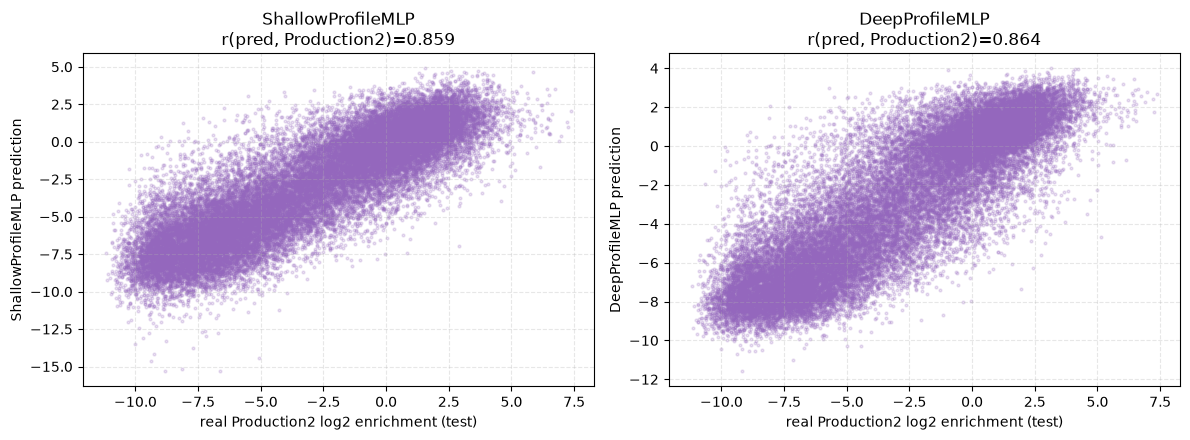

In [11]:
mlp_recovery_dfs = {}
for name, r in results.items():
    mlp_recovery_dfs[name] = recovery_table(y_test_p2, r["pred_test"], len(idx_test))
    print(f"{name}: recovery of the real top-k% (Production2) within the model's own top-k%:")
    display(mlp_recovery_dfs[name])

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, (name, r) in zip(axes, results.items()):
    ax.scatter(y_test_p2, r["pred_test"], s=4, alpha=0.2, color="tab:purple")
    ax.set_xlabel("real Production2 log2 enrichment (test)")
    ax.set_ylabel(f"{name} prediction")
    ax.set_title(f"{name}\nr(pred, Production2)={r['r_vs_p2']:.3f}")
    ax.grid(True, linestyle="--", alpha=0.3)
fig.tight_layout()
plt.show()

## 6. Summary: Potts regression vs ShallowProfileMLP vs DeepProfileMLP

All three trained on the SAME 40% of variants (`Production1` target only), evaluated on the
SAME held-out 60% against BOTH replicates.

In [12]:
summary_df = pd.DataFrame({
    "Potts regression":  dict(r_vs_Production1=r_potts_vs_p1, r_vs_Production2=r_potts_vs_p2),
    **{name: dict(r_vs_Production1=r["r_vs_p1"], r_vs_Production2=r["r_vs_p2"]) for name, r in results.items()},
}).T
summary_df.loc["r_replicate_ceiling (reference)"] = [np.nan, r_replicate_ceiling]
summary_df

print(f"({len(idx_train):,} training variants, {len(idx_test):,} held-out test variants, "
      f"seed=0 throughout)")
summary_df

(21,848 training variants, 32,773 held-out test variants, seed=0 throughout)


,r_vs_Production1,r_vs_Production2
Potts regression,0.797797,0.796811
ShallowProfileMLP,0.860317,0.859349
DeepProfileMLP,0.864760,0.864322
r_replicate_ceiling (reference),NaN,0.890568


### 6a. Percentile-recovery ceiling: Production1 vs Production2

`r_replicate_ceiling` (section 3) is the Pearson-r ceiling -- no fitted method can be expected
to beat how well the two real replicates agree with each other. This is the same idea at the
percentile-recovery level: treat the RAW `Production1` measurement itself (no model at all,
same held-out rows) as a "prediction" of `Production2`, and run it through the exact same
`recovery_table` as every fitted method above. Shows how much of the gap between a fitted
method and 100% recovery is fundamentally unreachable (replicate noise) vs. actually missing
model capacity.

In [13]:
p1_vs_p2_recovery_df = recovery_table(y_test_p2, y_test_p1, len(idx_test))
print("Raw Production1 (no model): recovery of the real top-k% (Production2) within "
      "Production1's own top-k%:")
display(p1_vs_p2_recovery_df)


Raw Production1 (no model): recovery of the real top-k% (Production2) within Production1's own top-k%:


,k,recovery,random_baseline
percentile,,,
1,327,0.152905,0.01
2,655,0.200000,0.02
5,1638,0.344322,0.05
10,3277,0.472078,0.10
20,6554,0.635185,0.20
30,9831,0.765741,0.30
50,16386,0.919993,0.50
70,22941,0.917571,0.70
100,32773,1.000000,1.00


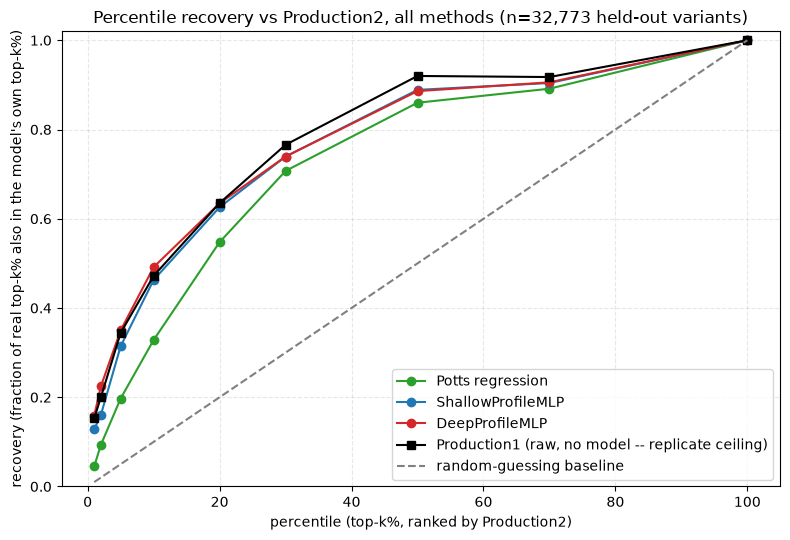

In [14]:
fig, ax = plt.subplots(figsize=(8, 5.5))
colors = {"Potts regression": "tab:green", "ShallowProfileMLP": "tab:blue", "DeepProfileMLP": "tab:red"}

for name, df_r in {"Potts regression": potts_recovery_df, **mlp_recovery_dfs}.items():
    ax.plot(df_r.index, df_r["recovery"], marker="o", color=colors[name], label=name)
ax.plot(p1_vs_p2_recovery_df.index, p1_vs_p2_recovery_df["recovery"], marker="s", linestyle="-",
        color="black", label="Production1 (raw, no model -- replicate ceiling)")
ax.plot(potts_recovery_df.index, potts_recovery_df["random_baseline"], linestyle="--",
        color="gray", label="random-guessing baseline")
ax.set_xlabel("percentile (top-k%, ranked by Production2)")
ax.set_ylabel("recovery (fraction of real top-k% also in the model's own top-k%)")
ax.set_ylim(0, 1.02)
ax.set_title(f"Percentile recovery vs Production2, all methods (n={len(idx_test):,} held-out variants)")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.3)
fig.tight_layout()
plt.show()


## 7. Score / log enrichment vs Production2, every method side by side

Plain scatter, x-axis fixed to the real `Production2` log2 enrichment (held-out test rows)
throughout, y-axis = each method's own score/prediction on those same rows -- plus the raw
`Production1` measurement itself as a 4th, "no model" reference panel. All four share the
same x-axis range for a direct visual comparison, with a y = x reference diagonal in each
panel (all four are fit/measured directly against the log2-enrichment scale, so points
hugging the diagonal indicate the score isn't just correlated but actually on the right
scale).

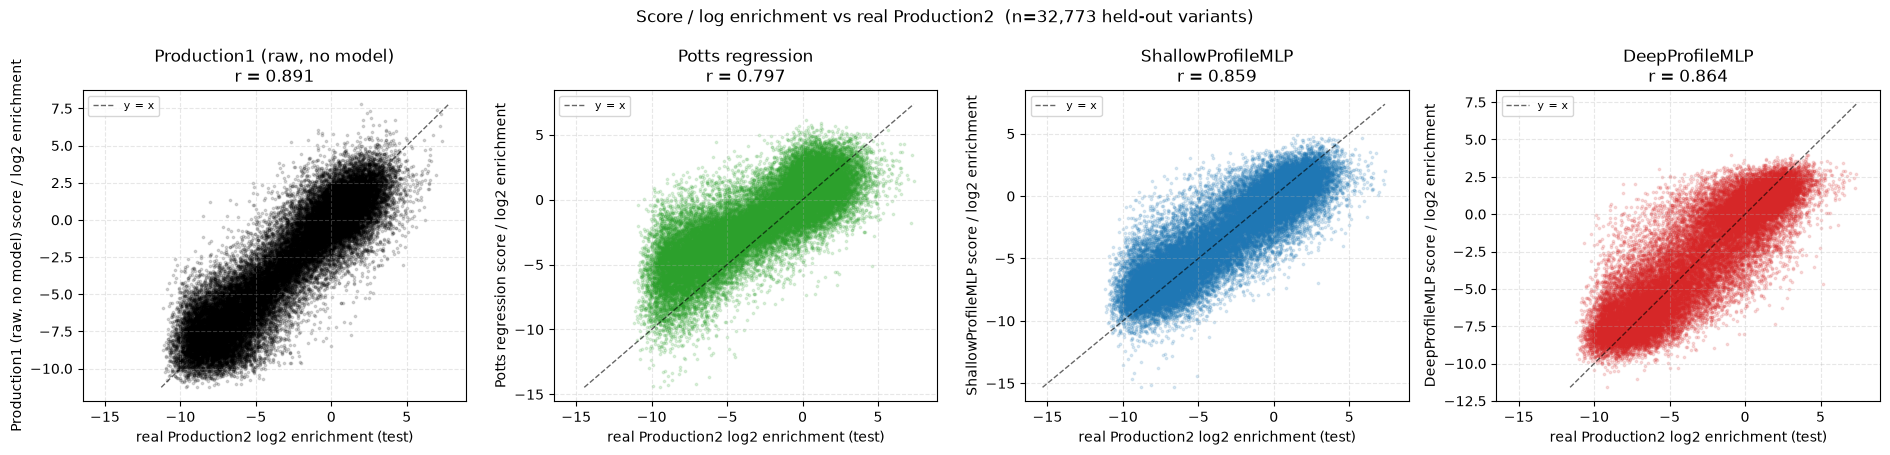

In [15]:
panels = [
    ("Production1 (raw, no model)", y_test_p1, r_replicate_ceiling, "black"),
    ("Potts regression",            pred_potts_test,                        r_potts_vs_p2,          "tab:green"),
    ("ShallowProfileMLP",           results["ShallowProfileMLP"]["pred_test"], results["ShallowProfileMLP"]["r_vs_p2"], "tab:blue"),
    ("DeepProfileMLP",              results["DeepProfileMLP"]["pred_test"],    results["DeepProfileMLP"]["r_vs_p2"],    "tab:red"),
]

fig, axes = plt.subplots(1, 4, figsize=(19, 4.6), sharex=True, sharey=False)
x_lo, x_hi = y_test_p2.min(), y_test_p2.max()

for ax, (name, y_vals, r_val, color) in zip(axes, panels):
    ax.scatter(y_test_p2, y_vals, s=3, alpha=0.15, color=color)
    lo = min(x_lo, np.min(y_vals))
    hi = max(x_hi, np.max(y_vals))
    ax.plot([lo, hi], [lo, hi], "k--", lw=1, alpha=0.6, label="y = x")
    ax.set_xlabel("real Production2 log2 enrichment (test)")
    ax.set_ylabel(f"{name} score / log2 enrichment")
    ax.set_title(f"{name}\nr = {r_val:.3f}")
    ax.grid(True, linestyle="--", alpha=0.3)
    ax.legend(fontsize=8, loc="upper left")

fig.suptitle(f"Score / log enrichment vs real Production2  (n={len(idx_test):,} held-out variants)")
fig.tight_layout()
plt.show()
